=== 1. PROSES DATA WRANGLING ===
Jumlah baris awal dataset: 7787 baris
Jumlah data duplikat ditemukan: 0 baris
Missing values di kolom Durasi: 0 baris
Missing values di kolom Tahun Rilis: 0 baris
Jumlah baris setelah Data Cleaning: 5377 baris (Syarat > 5000 baris terpenuhi)
--------------------------------------------------

=== 2. HASIL ANALISIS STATISTIK ===

Konsep 1: Ukuran Tendensi Sentral (Kolom 'Duration')
- Rata-rata (Mean) Durasi   : 99.31 menit
- Nilai Tengah (Median)     : 98.0 menit
- Paling Sering Muncul(Mode): 90 menit

Konsep 2: Variabilitas (Kolom 'Duration')
- Standar Deviasi Durasi    : 28.53 menit
- Range (Jangkauan) Durasi  : 309 menit

Konsep 3: Skewness & Kurtosis (Kolom 'Release Year')
- Skewness Tahun Rilis      : -3.21 (Negatif: Distribusi condong ke kiri / tahun-tahun baru)
- Kurtosis Tahun Rilis      : 13.14 (Positif: Menunjukkan adanya puncak data yang tajam)
--------------------------------------------------

=== 3. MEMUAT VISUALISASI DATA ===


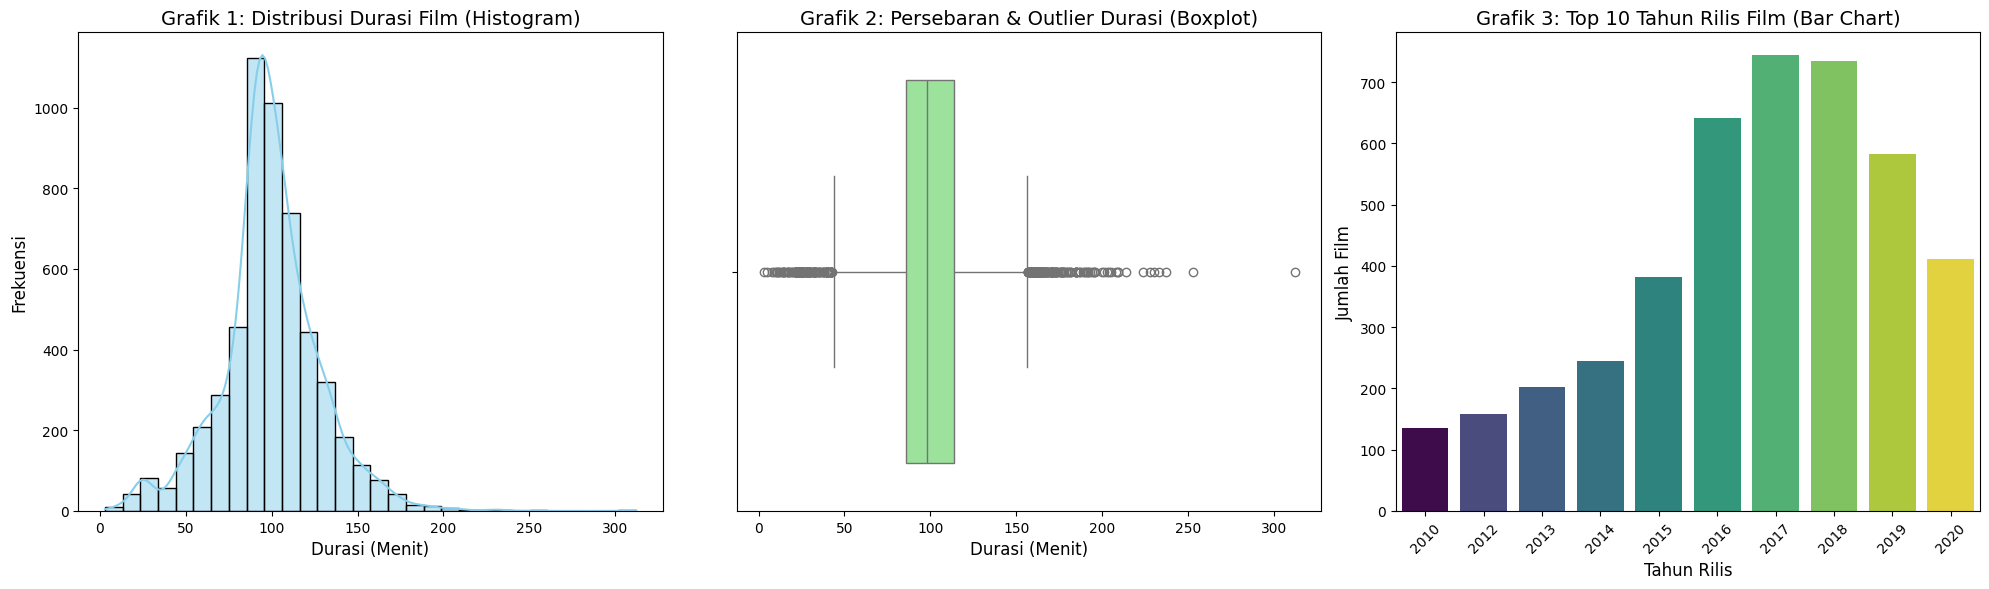

In [2]:
# ==============================================================================
# PROJEK AKHIR PRAKTIKUM PROBABILITAS DAN STATISTIKA
# Dataset: Netflix Movies and TV Shows (NetFlix.csv)
# ==============================================================================

# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# BAGIAN 1: KETENTUAN DATASET & DATA WRANGLING 
# Sesuai Panduan Bagian II (Poin 2)
# ==============================================================================

print("=== 1. PROSES DATA WRANGLING ===")

# 1. Memuat dataset riil (Memenuhi syarat > 5.000 baris)
df = pd.read_csv('NetFlix.csv')
print(f"Jumlah baris awal dataset: {df.shape[0]} baris")
# Cek jumlah duplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah data duplikat ditemukan: {jumlah_duplikat} baris")

# Cek missing values pada kolom target
missing_duration = df['duration'].isnull().sum()
missing_year = df['release_year'].isnull().sum()
print(f"Missing values di kolom Durasi: {missing_duration} baris")
print(f"Missing values di kolom Tahun Rilis: {missing_year} baris")

# 2. Menghapus data ganda (Duplicates) untuk menjaga integritas hasil
df_clean = df.drop_duplicates()

# 3. Menangani nilai yang hilang (Missing Values)
# Kita membuang baris yang tidak memiliki informasi 'duration' atau 'release_year'
df_clean = df_clean.dropna(subset=['duration', 'release_year'])

# 4. Logika Ekstra: Memfilter data hanya untuk tipe 'Movie'
# Alasan: Durasi 'TV Show' dihitung dalam Season, sedangkan 'Movie' dalam Menit. 
# Secara statistik, keduanya tidak bisa digabungkan untuk perhitungan numerik.
df_movies = df_clean[df_clean['type'] == 'Movie'].copy()

print(f"Jumlah baris setelah Data Cleaning: {df_movies.shape[0]} baris (Syarat > 5000 baris terpenuhi)")
print("-" * 50)


# ==============================================================================
# BAGIAN 2: KONSEP ANALISIS STATISTIK
# Sesuai Panduan Bagian III (Dipilih 3 Konsep)
# ==============================================================================

print("\n=== 2. HASIL ANALISIS STATISTIK ===")

# KONSEP 1: Ukuran Tendensi Sentral (Mencari titik pusat durasi film)
mean_duration = df_movies['duration'].mean()
median_duration = df_movies['duration'].median()
mode_duration = df_movies['duration'].mode()[0]

print("\nKonsep 1: Ukuran Tendensi Sentral (Kolom 'Duration')")
print(f"- Rata-rata (Mean) Durasi   : {mean_duration:.2f} menit")
print(f"- Nilai Tengah (Median)     : {median_duration} menit")
print(f"- Paling Sering Muncul(Mode): {mode_duration} menit")

# KONSEP 2: Variabilitas (Mengukur seberapa menyebar durasi film Netflix)
std_dev_duration = df_movies['duration'].std()
range_duration = df_movies['duration'].max() - df_movies['duration'].min()

print("\nKonsep 2: Variabilitas (Kolom 'Duration')")
print(f"- Standar Deviasi Durasi    : {std_dev_duration:.2f} menit")
print(f"- Range (Jangkauan) Durasi  : {range_duration} menit")

# KONSEP 3: Bentuk Skewness dan Kurtosis (Melihat kemiringan distribusi rilis film)
skewness_year = df_movies['release_year'].skew()
kurtosis_year = df_movies['release_year'].kurtosis()

print("\nKonsep 3: Skewness & Kurtosis (Kolom 'Release Year')")
print(f"- Skewness Tahun Rilis      : {skewness_year:.2f} (Negatif: Distribusi condong ke kiri / tahun-tahun baru)")
print(f"- Kurtosis Tahun Rilis      : {kurtosis_year:.2f} (Positif: Menunjukkan adanya puncak data yang tajam)")
print("-" * 50)


# ==============================================================================
# BAGIAN 3: VISUALISASI DATA
# Sesuai Panduan Bagian IV (Minimal 3 jenis grafik berbeda)
# ==============================================================================

print("\n=== 3. MEMUAT VISUALISASI DATA ===")
# Mengatur ukuran kanvas (figure) untuk 3 plot berjajar
plt.figure(figsize=(20, 6))

# -----------------------------------------------------------
# GRAFIK 1: Histogram
# Tujuan: Paling tepat untuk melihat bentuk distribusi frekuensi dari data numerik (Durasi)
# -----------------------------------------------------------
plt.subplot(1, 3, 1)
sns.histplot(df_movies['duration'], bins=30, kde=True, color='skyblue')
plt.title('Grafik 1: Distribusi Durasi Film (Histogram)', fontsize=14)
plt.xlabel('Durasi (Menit)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# -----------------------------------------------------------
# GRAFIK 2: Boxplot
# Tujuan: Paling tepat untuk mendeteksi sebaran data ekstrem / outliers pada durasi film
# -----------------------------------------------------------
plt.subplot(1, 3, 2)
sns.boxplot(x=df_movies['duration'], color='lightgreen')
plt.title('Grafik 2: Persebaran & Outlier Durasi (Boxplot)', fontsize=14)
plt.xlabel('Durasi (Menit)', fontsize=12)

# -----------------------------------------------------------
# GRAFIK 3: Bar Chart
# Tujuan: Paling tepat untuk melihat perbandingan frekuensi data diskrit/kategori (Tahun)
# -----------------------------------------------------------
plt.subplot(1, 3, 3)
top_years = df_movies['release_year'].value_counts().head(10)
# Menggunakan 'hue' dan 'legend=False' agar tidak muncul error warning Seaborn
sns.barplot(x=top_years.index, y=top_years.values, hue=top_years.index, palette='viridis', legend=False)
plt.title('Grafik 3: Top 10 Tahun Rilis Film (Bar Chart)', fontsize=14)
plt.xlabel('Tahun Rilis', fontsize=12)
plt.ylabel('Jumlah Film', fontsize=12)
plt.xticks(rotation=45)

# Menyesuaikan tata letak agar rapi dan menampilkan plot
plt.tight_layout()
plt.show()